# Evasion Attacks and Defenses on Hugging Face Models using ART

In this notebook we will go over how to use ART to perform evasion attacks on a Hugging Face image classifier. We will be fine-tuning a pre-trained Data-efficient Image Transformer (DeiT) model available from Hugging Face on the CIFAR-10 dataset. We will apply the Projected Gradient Descent (PGD) attack on this model using ART functionality. Then we will be performing adversarial training to defend against such evasion attacks.

Afterwards, we will be demonstrating further functionality with Hugging Face models such as using the PyTorch Image Models (timm) library or a custom Hugging Face model using a created config.

In addition to the core ART dependencies you will need to install Pytorch and the Transformers library:

`pip install torch torchvision`

`pip install transformers`

Let's look at how we can use ART to both attack and defend Hugging Face models!


In [ ]:
#Set up new environment and installs :)

!sudo apt install python3.10-venv
!source my_env/bin/deactivate  # Deactivate current environment
!rm -rf my_env  # Remove the old environment directory
!python -m venv my_env  # Create a fresh environment
!source my_env/bin/activate  # Activate the new environment
!pip install torch torchvision transformers  # Reinstall PyTorch and related libraries
!pip install adversarial-robustness-toolbox

#!pip install --upgrade torch torchvision transformers

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  python3-pip-whl python3-setuptools-whl
The following NEW packages will be installed:
  python3-pip-whl python3-setuptools-whl python3.10-venv
0 upgraded, 3 newly installed, 0 to remove and 29 not upgraded.
Need to get 2,474 kB of archives.
After this operation, 2,885 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 python3-pip-whl all 22.0.2+dfsg-1ubuntu0.5 [1,680 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 python3-setuptools-whl all 59.6.0-1.2ubuntu0.22.04.2 [788 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 python3.10-venv amd64 3.10.12-1~22.04.9 [5,722 B]
Fetched 2,474 kB in 1s (2,740 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend ca

In [ ]:
import os
from os.path import abspath
import subprocess
import sys

modulePath = os.path.abspath(os.path.join('..'))
if modulePath not in sys.path:
    sys.path.append(modulePath)

import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
import transformers

from art import config
from art.estimators.classification.hugging_face import HuggingFaceClassifierPyTorch
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import ProjectedGradientDescentPyTorch # attack
from art.defences.trainer import AdversarialTrainerMadryPGD # for fine tuning
from art.utils import load_dataset, get_file
from torchvision.models import resnet50, ResNet50_Weights


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
#Dataset imports

import pandas as pd
from PIL import Image
from pathlib import Path
import cv2
import csv

%matplotlib inline
import matplotlib.pyplot as plt

np.random.seed(301)

In [ ]:
#Confusion Matrix
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Granting access to Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Ensure your class folder matches this location.

In [ ]:
# Replace with your path to dataset (class folder)
!unzip './drive/My Drive/TrafficSignDataset.zip'

Streaming output truncated to the last 5000 lines.
  inflating: TrainingFolder/005_0004.png  
  inflating: __MACOSX/TrainingFolder/._005_0004.png  
  inflating: TrainingFolder/029_0009.png  
  inflating: __MACOSX/TrainingFolder/._029_0009.png  
  inflating: TrainingFolder/055_1_0032.png  
  inflating: __MACOSX/TrainingFolder/._055_1_0032.png  
  inflating: TrainingFolder/007_1_0069.png  
  inflating: __MACOSX/TrainingFolder/._007_1_0069.png  
  inflating: TrainingFolder/030_1_0041.png  
  inflating: __MACOSX/TrainingFolder/._030_1_0041.png  
  inflating: TrainingFolder/030_1_0055.png  
  inflating: __MACOSX/TrainingFolder/._030_1_0055.png  
  inflating: TrainingFolder/028_0009.png  
  inflating: __MACOSX/TrainingFolder/._028_0009.png  
  inflating: TrainingFolder/055_1_0026.png  
  inflating: __MACOSX/TrainingFolder/._055_1_0026.png  
  inflating: TrainingFolder/000_0032.png  
  inflating: __MACOSX/TrainingFolder/._000_0032.png  
  inflating: TrainingFolder/007_1_0055.png  
  inflating

Data preprocessing

In [ ]:
label_names = [
    "Speed limit (5km/h)",
    "Speed limit (15km/h)",
    "Speed limit (30km/h)",
    "Speed limit (40km/h)",
    "Speed limit (50km/h)",
    "Speed limit (60km/h)",
    "Speed limit (70km/h)",
    "Speed limit (80km/h)",
    "Dont Go straight or left",
    "Dont Go straight or Right",
    "Dont Go straight",
    "Dont Go Left",
    "Dont Go Left or Right",
    "Dont Go Right",
    "Dont overtake from Left",
    "No Uturn",
    "No Car",
    "No horn",
    "Go straight or right",
    "Go straight",
    "Go Left",
    "Go Left or right",
    "Go Right",
    "keep Left",
    "keep Right",
    "Roundabout mandatory",
    "watch out for cars",
    "Horn",
    "Bicycles crossing",
    "Uturn",
    "Road Divider",
    "Traffic signals",
    "Danger Ahead",
    "Zebra Crossing",
    "Bicycles crossing",
    "Children crossing",
    "Dangerous curve to the left",
    "Dangerous curve to the right",
    "Unknown1",
    "Unknown2",
    "Unknown3",
    "Go right or straight",
    "Go left or straight",
    "Unknown4",
    "ZigZag Curve",
    "Train Crossing",
    "Under Construction",
    "Unknown5",
    "Fences",
    "Heavy Vehicle Accidents",
    "Unknown6",
    "Give Way",
    "No stopping",
    "No entry",
    "Unknown7",
    "Unknown8",
]

In [ ]:
def findMatchingRow(csvFile, searchString, columnIndex=0):
    with open(csvFile, 'r') as file:
        reader = csv.reader(file)
        for row in reader:
            if row[columnIndex] == searchString:
                return row
    return None

In [ ]:
def processImages(dataDir, imgSize=(128, 128), isTraining = True):
    images = []
    labels = []
    for imgName in os.listdir(dataDir):
      # Import and normalize images
        imgPath = os.path.join(dataDir, imgName)
        img = cv2.imread(imgPath)
        img = cv2.resize(img, imgSize)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = img.transpose(2, 0, 1)

        images.append(img)

      # Add label to list
        if isTraining:
          #row = findMatchingRow("/drive/MyDrive/TrafficSignDataset/TrainingLabels.csv", imgName)
          row = findMatchingRow("./TrainingLabels.csv", imgName)
        else:
          #row = findMatchingRow("/drive/MyDrive/TrafficSignDataset/TestingLabels.csv", imgName)
          row = findMatchingRow("./TestingLabels.csv", imgName)
        labels.append(int(row[1]))

    return np.array(images), np.array(labels)

In [ ]:
#trainPath = "/drive/MyDrive/TrafficSignDataset/TrainingFolder"
#testPath = "/drive/MyDrive/TrafficSignDataset/TestingFolder"
trainPath = "./TrainingFolder"
testPath = "./TestingFolder"
trainImages, trainLabels = processImages(trainPath)
testImages, testLabels = processImages(testPath, isTraining=False)

# Convert values to be between 0 and 1
trainImages = trainImages.astype('float32') / 255.0
testImages = testImages.astype('float32') / 255.0

In [ ]:
print(trainImages.shape)

(4170, 3, 128, 128)


In [ ]:
# Train subset
x_train = trainImages
y_train = trainLabels

# Test subset
x_test = testImages
y_test = testLabels

classes = np.unique(y_train)
samples_per_class = 100

x_subset = []
y_subset = []
# more subsets

for c in classes:
    indices = y_train == c
    x_subset.append(x_train[indices][:samples_per_class])
    y_subset.append(y_train[indices][:samples_per_class])

x_subset = np.concatenate(x_subset)
y_subset = np.concatenate(y_subset)

print(f'x_subset:', x_subset.dtype, x_subset.shape)
print(f'y_subset:', y_subset.dtype, y_subset.shape)

x_subset: float32 (2934, 3, 128, 128)
y_subset: int64 (2934,)


In [ ]:
# Create state_dicts directory for saving models

if not os.path.isdir('./state_dicts'):
    os.mkdir('./state_dicts')

## Regular Training with ART

We will first see how to load a model into ART's HuggingFaceClassifierPyTorch, train it, and attack it with PGD.

In [ ]:
# model = transformers.AutoModelForImageClassification.from_pretrained(
#     'dima806/traffic_sign_detection',
#     ignore_mismatched_sizes=True,
#     num_labels=10
# )

model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

numClasses = 58
model.fc = torch.nn.Linear(model.fc.in_features, numClasses)
# Put path to the project in your drive here
#myFile = Path("drive/MyDrive/bestModel.pth")
myFile = Path("./bestModel.pth")
if myFile.is_file():
  model.load_state_dict(torch.load(myFile))

model.eval()


#resize_transform = transforms.Resize((224, 224))

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = torch.nn.CrossEntropyLoss()
num_classes = len(np.unique(y_train))

# hf_model = HuggingFaceClassifierPyTorch(
#     model=model,
#     loss=loss_fn,
#     optimizer=optimizer,
#     input_shape=(3, 128, 128),
#     nb_classes=num_classes,
#     clip_values=(0, 1),
#     processor=resize_transform
# )

classifier = PyTorchClassifier(clip_values=(0.0, 1.0),
                             model=model,
                             nb_classes=58,
                             input_shape=(3,128,128),
                             loss=loss_fn,
                             optimizer=optimizer)


classifier.fit(
    trainImages,
    trainLabels,
    nb_epochs=10,
    training_mode=True,
    batch_size=25,
    verbose=True
    )

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s]


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
# load saved model if it already exists, otherwise train it

model_checkpoint_path = '/content/state_dicts/traffic_detection_model.pt'
if os.path.isfile(model_checkpoint_path):
    classifier.model.load_state_dict(torch.load(model_checkpoint_path, map_location=device))
    print('loaded model checkpoint')
else:
    classifier.fit(x_subset, y_subset, nb_epochs=5)
    torch.save(classifier.model.state_dict(), model_checkpoint_path)
    print('saved model checkpoint')

saved model checkpoint


Training takes too long. Checkpoint and save it on a file included in the Google Drive for students.

In [ ]:
outputs = classifier.predict(x_test)
clean_preds = np.argmax(outputs, axis=1)
clean_acc = np.mean(clean_preds == y_test)
print('clean accuracy:', clean_acc)

clean accuracy: 0.9277833500501504


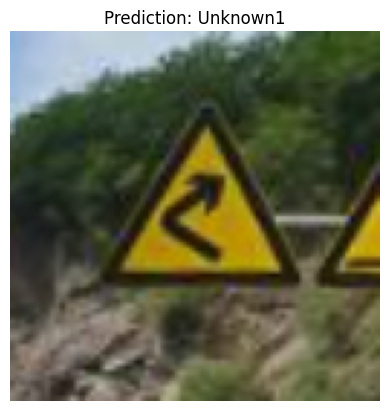

In [ ]:
index = 5
plt.imshow(np.transpose(x_test[index], (1, 2, 0)))
plt.title(f'Prediction: {label_names[clean_preds[index]]}')
plt.axis('off')
plt.show()

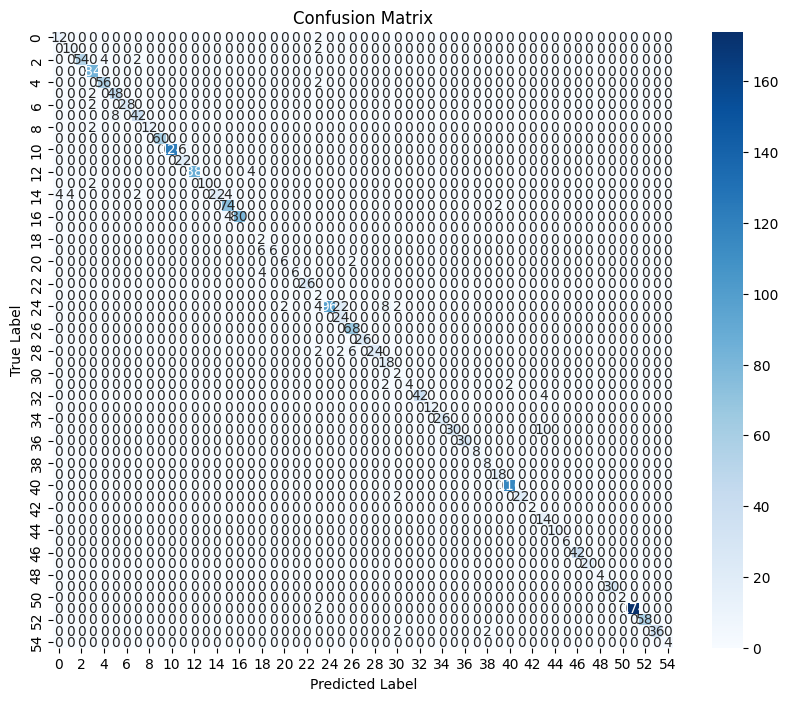

In [ ]:
# Use the predictions made earlier in the code: outputs
clean_preds = np.argmax(outputs, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_test, clean_preds)

# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Adversarial Examples

In [ ]:
# load adversarial samples if they already exist, otherwise generate them

adv_samples_path = './state_dicts/x_adv_base.npy'
if os.path.isfile(adv_samples_path):
    x_adv = np.load(adv_samples_path)
else:
    attacker = ProjectedGradientDescentPyTorch(classifier, eps=8/255, eps_step=1/255)
    x_adv = attacker.generate(x_subset)
    np.save(adv_samples_path, x_adv)

outputs = classifier.predict(x_adv)
adv_preds = np.argmax(outputs, axis=1)
adv_acc = np.mean(adv_preds == y_subset)
print('adversarial accuracy:', adv_acc)

PGD - Batches:   0%|          | 0/92 [00:00<?, ?it/s]

adversarial accuracy: 0.0


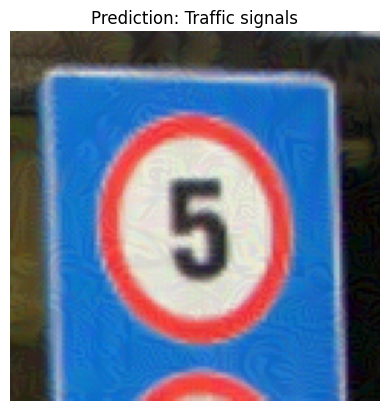

In [ ]:
plt.imshow(np.transpose(x_adv[1], (1, 2, 0)))
plt.title(f'Prediction: {label_names[adv_preds[1]]}')
plt.axis('off')
plt.show()

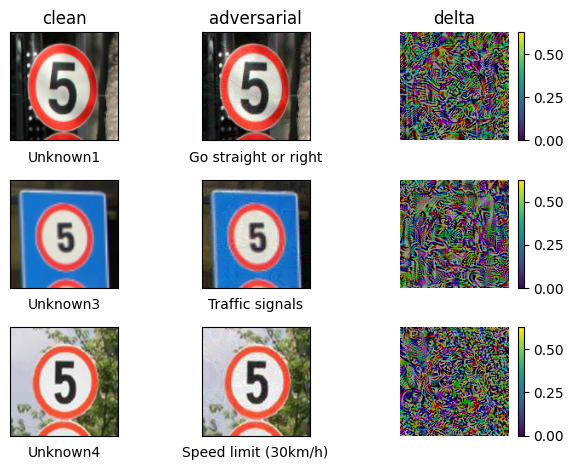

In [ ]:
# We can display the adversarial examples to highlight the added perturbation to the original sample.

# shift to have min 0 and make perturbations 10x larger to visualize them.
delta = ((x_subset - x_adv) + 8/255) * 10

fig, axs = plt.subplots(3, 3)
for i in range(3):
    axs[i, 0].imshow(np.transpose(x_subset[i], (1, 2, 0)))
    axs[i, 0].set_xlabel(label_names[clean_preds[i]])
    axs[i, 0].tick_params(axis='both', which='both',length=0)
    axs[i, 0].axes.xaxis.set_ticklabels([])
    axs[i, 0].axes.yaxis.set_ticklabels([])
    axs[i, 1].imshow(np.transpose(x_adv[i], (1, 2, 0)))
    axs[i, 1].axes.xaxis.set_ticklabels([])
    axs[i, 1].axes.yaxis.set_ticklabels([])
    axs[i, 1].tick_params(axis='both', which='both',length=0)
    axs[i, 1].set_xlabel(label_names[adv_preds[i]])
    im = axs[i, 2].imshow(np.transpose(delta[i], (1, 2, 0)))
    axs[i, 2].axis('off')
    fig.colorbar(im)

axs[0, 0].set_title('clean')
axs[0, 1].set_title('adversarial')
axs[0, 2].set_title('delta')
plt.tight_layout()